# Transaction Costs Estimation

Objective: derive a single transaction cost estimate (bid-ask spread as % of mid-price) suitable for use in Monte Carlo simulations.

Analysis covers:
1. Data overview and cleaning  
2. Time-series of average transaction costs  
3. Market-cap weighted vs. equal-weighted averages  
4. Full-sample vs. recency-weighted estimates  
5. Distribution of transaction costs by market-cap quintile (size)  
6. Final estimate summary

In [26]:
import pandas as pd
from regimeaware.constants import DataConstants

crsp = pd.read_pickle(rf"{DataConstants.WDIR.value}/data/crsp.pkl")
bas = crsp["ask"] - crsp["bid"]  # Bid-ask spread
mid = (crsp["ask"] + crsp["bid"]) / 2  # Mid price
tcost = bas / mid  # Transaction cost as a percentage of the mid price
mcap = crsp["prc"] * crsp["shrout"]  # Market capitalization

## 1. Data Overview

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── Clean: keep rows with valid bid/ask and positive mid ──────────────────────
df = crsp[["bid", "ask", "mktcap"]].copy()
df["bas"] = df["ask"] - df["bid"]
df["mid"] = (df["ask"] + df["bid"]) / 2
df["tcost"] = df["bas"] / df["mid"]          # half-spread (one-way) as % of mid

mask = (
    df["bid"].notna() & df["ask"].notna() &
    (df["mid"] > 0) &
    (df["tcost"] > 0) & (df["tcost"] < 1) &  # drop extreme outliers (>100%)
    (df["mktcap"] > 0) &
    (df.index.get_level_values("date") >= "1985-01-01")  # restrict to 1985+
)
df = df.loc[mask].copy()

dates = df.index.get_level_values("date")
print(f"Clean observations: {len(df):,}")
print(f"Date range: {dates.min().date()} → {dates.max().date()}")
print(f"Unique dates: {dates.nunique():,}  |  Unique stocks: {df.index.get_level_values('permno').nunique():,}")
print(f"\nTransaction cost summary (%):")
(df["tcost"] * 100).describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).round(4)

Clean observations: 2,067,861
Date range: 1985-01-31 → 2024-12-31
Unique dates: 479  |  Unique stocks: 18,912

Transaction cost summary (%):


count    2067861.0
mean        2.9007
std         5.2014
min         0.0001
10%         0.0462
25%         0.1717
50%         1.0885
75%         3.4483
90%         7.4215
95%        11.7647
99%           25.0
max        99.7859
Name: tcost, dtype: Float64

## 2. Time Series of Transaction Costs

Equal-weighted and market-cap weighted average bid-ask spread (% of mid) by month.

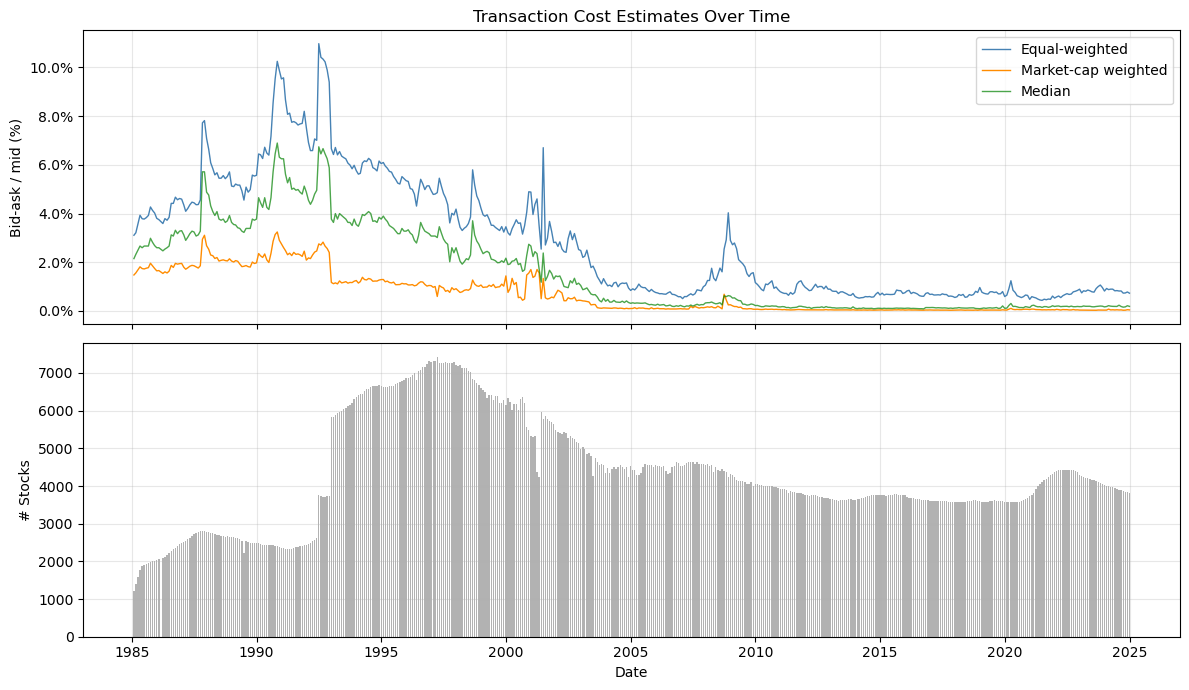

             ew        vw    median
count  479.0000  479.0000  479.0000
mean     2.8429    0.7163    1.5979
std      2.4638    0.8337    1.7525
min      0.4351    0.0288    0.0858
25%      0.7588    0.0466    0.1736
50%      1.4865    0.1452    0.3728
75%      4.7540    1.2131    3.1250
max     10.9778    3.2455    6.8966


In [29]:
# ── Monthly averages ──────────────────────────────────────────────────────────
def mcap_weighted_mean(grp):
    w = grp["mktcap"]
    return (grp["tcost"] * w).sum() / w.sum()

monthly = df.groupby("date").apply(
    lambda g: pd.Series({
        "ew":   g["tcost"].mean(),
        "vw":   mcap_weighted_mean(g),
        "median": g["tcost"].median(),
        "n_stocks": len(g),
    })
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(monthly.index, monthly["ew"] * 100, label="Equal-weighted", lw=1, color="steelblue")
ax.plot(monthly.index, monthly["vw"] * 100, label="Market-cap weighted", lw=1, color="darkorange")
ax.plot(monthly.index, monthly["median"] * 100, label="Median", lw=1, color="green", alpha=0.7)
ax.set_ylabel("Bid-ask / mid (%)")
ax.set_title("Transaction Cost Estimates Over Time")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(monthly.index, monthly["n_stocks"], width=20, color="gray", alpha=0.6)
ax2.set_ylabel("# Stocks")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(monthly[["ew","vw","median"]].mul(100).describe().round(4))

## 3. Weighting Scheme × Time Window

Costs have fallen dramatically with decimalization (~2001). We compare estimates under different time windows and weighting schemes.

In [30]:
end_date   = df.index.get_level_values("date").max()
cutoffs = {
    "Full sample":       None,
    "Post-decimalization (2001+)": pd.Timestamp("2001-01-01"),
    "Last 20 years":     end_date - pd.DateOffset(years=20),
    "Last 10 years":     end_date - pd.DateOffset(years=10),
    "Last 5 years":      end_date - pd.DateOffset(years=5),
}

rows = []
for label, cutoff in cutoffs.items():
    sub = df.loc[df.index.get_level_values("date") >= cutoff] if cutoff else df
    n  = len(sub)
    ew = sub["tcost"].mean()
    vw = (sub["tcost"] * sub["mktcap"]).sum() / sub["mktcap"].sum()
    med = sub["tcost"].median()

    # Exponential (recency) weighting within the window:
    # assign weight = exp(λ * rank/N) where rank is time-sorted
    sub_sorted = sub.sort_index(level="date")
    ranks = np.arange(len(sub_sorted), dtype=float)
    lam = 3.0  # decay strength
    exp_w = np.exp(lam * ranks / len(sub_sorted))
    exp_w /= exp_w.sum()
    ew_exp = (sub_sorted["tcost"].values * exp_w).sum()

    rows.append({"Window": label, "N obs": n,
                 "Equal-wtd (%)": ew * 100,
                 "MCap-wtd (%)": vw * 100,
                 "Median (%)": med * 100,
                 "Exp recency-wtd (%)": ew_exp * 100})

estimates = pd.DataFrame(rows).set_index("Window")
estimates["N obs"] = estimates["N obs"].map("{:,}".format)
print(estimates.round(4).to_string())

                                 N obs  Equal-wtd (%)  MCap-wtd (%)  Median (%)  Exp recency-wtd (%)
Window                                                                                              
Full sample                  2,067,861         2.9007        0.2042      1.0885               1.4890
Post-decimalization (2001+)  1,191,187         1.1867        0.0891      0.2484               0.8576
Last 20 years                  957,417         0.8885        0.0571      0.1834               0.7830
Last 10 years                  464,407         0.7127        0.0444      0.1489               0.7513
Last 5 years                   245,780         0.7203        0.0484      0.1826               0.7881


## 4. Distribution by Market-Cap Quintile (Size)

Smaller companies have wider spreads. We sort stocks into market-cap quintiles each month and compare transaction cost distributions.

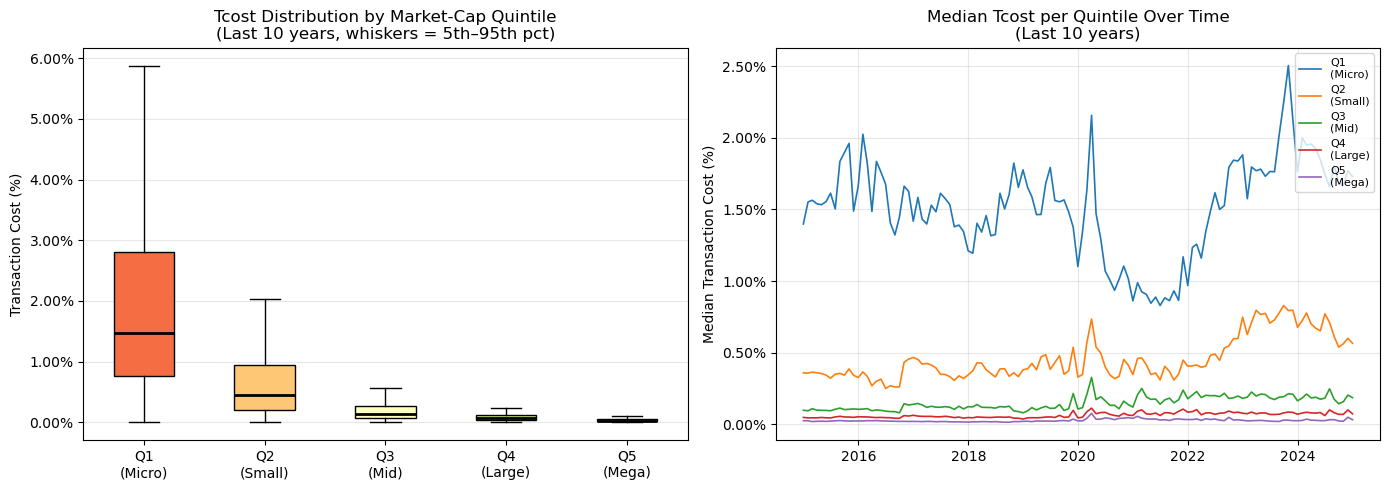


Summary (%) — Last 10 years:
               mean  median     p25     p75      n
Q1\n(Micro)  2.2292  1.4706  0.7547  2.8053  92932
Q2\n(Small)  0.9134  0.4415  0.2081  0.9406  92856
Q3\n(Mid)    0.2783   0.144  0.0781  0.2743  92855
Q4\n(Large)  0.0986   0.063  0.0341  0.1133  92855
Q5\n(Mega)    0.043   0.026  0.0146  0.0491  92909


In [31]:
# Use last 10 years for this analysis (post-decimalization, recent regime)
recent = df.loc[df.index.get_level_values("date") >= end_date - pd.DateOffset(years=10)].copy()

# Assign size quintile each month based on market cap
recent["size_q"] = recent.groupby("date")["mktcap"].transform(
    lambda x: pd.qcut(x, 5, labels=["Q1\n(Micro)", "Q2\n(Small)", "Q3\n(Mid)", "Q4\n(Large)", "Q5\n(Mega)"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Box plot ──────────────────────────────────────────────────────────────────
quintile_labels = ["Q1\n(Micro)", "Q2\n(Small)", "Q3\n(Mid)", "Q4\n(Large)", "Q5\n(Mega)"]
groups = [recent.loc[recent["size_q"] == q, "tcost"].dropna().values * 100
          for q in quintile_labels]

bp = axes[0].boxplot(groups, labels=quintile_labels, patch_artist=True,
                     showfliers=False, medianprops={"color": "black", "lw": 2})
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 5))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel("Transaction Cost (%)")
axes[0].set_title("Tcost Distribution by Market-Cap Quintile\n(Last 10 years, whiskers = 5th–95th pct)")
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))

# ── Median tcost per quintile over time ───────────────────────────────────────
q_time = (recent.groupby(["date", "size_q"])["tcost"]
          .median()
          .unstack("size_q")
          .mul(100))

for col in quintile_labels:
    if col in q_time.columns:
        axes[1].plot(q_time.index, q_time[col], label=col, lw=1.2)
axes[1].set_ylabel("Median Transaction Cost (%)")
axes[1].set_title("Median Tcost per Quintile Over Time\n(Last 10 years)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))

plt.tight_layout()
plt.show()

# Summary stats per quintile
summary_q = recent.groupby("size_q")["tcost"].agg(
    mean="mean", median="median", p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75), n="count"
).mul({"mean": 100, "median": 100, "p25": 100, "p75": 100, "n": 1})
summary_q.index = quintile_labels
summary_q["n"] = summary_q["n"].astype(int)
print("\nSummary (%) — Last 10 years:")
print(summary_q.round(4).to_string())

## 5. Final Estimate for Monte Carlo Simulations

We consolidate all estimates and select a single value. For a simulation universe of diversified stocks (not purely mega-cap), the **equal-weighted median over the post-decimalization period** is a reasonable baseline — it is resistant to outlier small stocks yet not dominated by the near-zero spreads of mega-caps.

In [32]:
# ── All candidate estimates (%) ───────────────────────────────────────────────
candidates = {
    # (window, method): value
    ("Full sample",            "Equal-weighted mean"):   df["tcost"].mean() * 100,
    ("Full sample",            "MCap-weighted mean"):    (df["tcost"] * df["mktcap"]).sum() / df["mktcap"].sum() * 100,
    ("Full sample",            "Median"):                df["tcost"].median() * 100,
    ("Post-dec (2001+)",       "Equal-weighted mean"):   None,
    ("Post-dec (2001+)",       "MCap-weighted mean"):    None,
    ("Post-dec (2001+)",       "Median"):                None,
    ("Last 10 years",          "Equal-weighted mean"):   None,
    ("Last 10 years",          "MCap-weighted mean"):    None,
    ("Last 10 years",          "Median"):                None,
}

# Fill in window-specific values
for cutoff_label, cutoff_dt in [
    ("Post-dec (2001+)", pd.Timestamp("2001-01-01")),
    ("Last 10 years",    end_date - pd.DateOffset(years=10)),
]:
    sub = df.loc[df.index.get_level_values("date") >= cutoff_dt]
    candidates[(cutoff_label, "Equal-weighted mean")]  = sub["tcost"].mean() * 100
    candidates[(cutoff_label, "MCap-weighted mean")]   = (sub["tcost"] * sub["mktcap"]).sum() / sub["mktcap"].sum() * 100
    candidates[(cutoff_label, "Median")]               = sub["tcost"].median() * 100

summary_df = (pd.Series(candidates)
              .rename_axis(["Window", "Method"])
              .rename("Tcost (%)")
              .reset_index()
              .pivot(index="Method", columns="Window", values="Tcost (%)"))

col_order = ["Full sample", "Post-dec (2001+)", "Last 10 years"]
summary_df = summary_df[col_order].round(4)
print(summary_df.to_string())

# ── Chosen estimate ──────────────────────────────────────────────────────────
# Post-decimalization median: robust to outlier small-caps, reflects modern market structure
TCOST_ESTIMATE = df.loc[df.index.get_level_values("date") >= pd.Timestamp("2001-01-01"), "tcost"].median()

print(f"\n{'─'*55}")
print(f"  Recommended estimate (post-dec median): {TCOST_ESTIMATE*100:.4f}%")
print(f"  Round-trip transaction cost:            {2*TCOST_ESTIMATE*100:.4f}%")
print(f"{'─'*55}")

Window               Full sample  Post-dec (2001+)  Last 10 years
Method                                                           
Equal-weighted mean       2.9007            1.1867         0.7127
MCap-weighted mean        0.2042            0.0891         0.0444
Median                    1.0885            0.2484         0.1489

───────────────────────────────────────────────────────
  Recommended estimate (post-dec median): 0.2484%
  Round-trip transaction cost:            0.4969%
───────────────────────────────────────────────────────


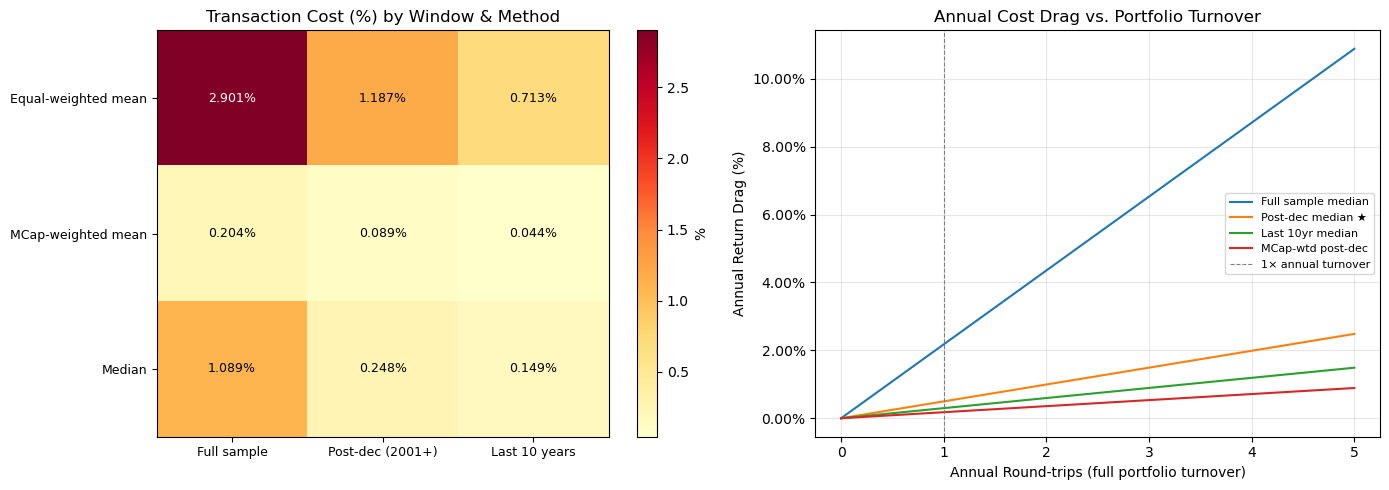

In [33]:
# ── Visualise the estimate space ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of all estimates
import matplotlib.colors as mcolors
data = summary_df.values
im = axes[0].imshow(data, cmap="YlOrRd", aspect="auto")
axes[0].set_xticks(range(len(summary_df.columns)))
axes[0].set_xticklabels(summary_df.columns, fontsize=9)
axes[0].set_yticks(range(len(summary_df.index)))
axes[0].set_yticklabels(summary_df.index, fontsize=9)
axes[0].set_title("Transaction Cost (%) by Window & Method")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        axes[0].text(j, i, f"{data[i,j]:.3f}%", ha="center", va="center",
                     fontsize=9, color="black" if data[i,j] < data.max()/2 else "white")
plt.colorbar(im, ax=axes[0], label="%")

# Sensitivity: annualised drag on a portfolio with N round-trips per year
turnover_pa = np.arange(0, 5.25, 0.25)          # annual round-trips (full portfolio)
for label, est in [
    ("Full sample median", df["tcost"].median()),
    ("Post-dec median ★",  TCOST_ESTIMATE),
    ("Last 10yr median",   df.loc[df.index.get_level_values("date") >= end_date - pd.DateOffset(years=10), "tcost"].median()),
    ("MCap-wtd post-dec",  (lambda s: (s["tcost"]*s["mktcap"]).sum()/s["mktcap"].sum())(
        df.loc[df.index.get_level_values("date") >= pd.Timestamp("2001-01-01")])),
]:
    drag = turnover_pa * 2 * est * 100   # round-trip = 2× one-way
    axes[1].plot(turnover_pa, drag, label=label, lw=1.5)

axes[1].axvline(1.0, ls="--", color="gray", lw=0.8, label="1× annual turnover")
axes[1].set_xlabel("Annual Round-trips (full portfolio turnover)")
axes[1].set_ylabel("Annual Return Drag (%)")
axes[1].set_title("Annual Cost Drag vs. Portfolio Turnover")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))

plt.tight_layout()
plt.show()